<a href="https://colab.research.google.com/github/jeeen0/cv-2026-lab/blob/main/ex08_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EX.08-２

# 8-2

In [ ]:
# https://tutorials.pytorch.kr/beginner/blitz/cifar10_tutorial.html#sphx-glr-beginner-blitz-cifar10-tutorial-py
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

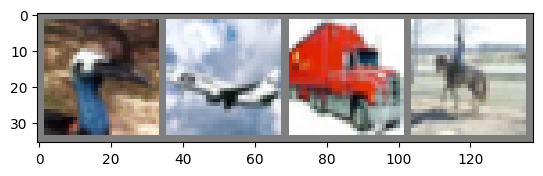

bird  plane truck horse


In [ ]:
# 이미지를 보여주기 위한 함수
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# 학습용 이미지를 무작위로 가져오기
dataiter = iter(trainloader)
images, labels = next(dataiter)

# 이미지 보여주기
imshow(torchvision.utils.make_grid(images))
# 정답(label) 출력
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # 배치를 제외한 모든 차원을 평탄화(flatten)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [ ]:
for epoch in range(2):   # 데이터셋을 수차례 반복합니다.

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # [inputs, labels]의 목록인 data로부터 입력을 받은 후;
        inputs, labels = data

        # 변화도(Gradient) 매개변수를 0으로 만들고
        optimizer.zero_grad()

        # 순전파 + 역전파 + 최적화를 한 후
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # 통계를 출력합니다.
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.202
[1,  4000] loss: 1.891
[1,  6000] loss: 1.707
[1,  8000] loss: 1.622
[1, 10000] loss: 1.536
[1, 12000] loss: 1.479
[2,  2000] loss: 1.393
[2,  4000] loss: 1.395
[2,  6000] loss: 1.350
[2,  8000] loss: 1.307
[2, 10000] loss: 1.321
[2, 12000] loss: 1.283
Finished Training


In [ ]:
# save the CNN model
# PATH = './cifar_net.pth'
# torch.save(net.state_dict(), PATH) # save
# net = Net()
# net.load_state_dict(torch.load(PATH)) # load

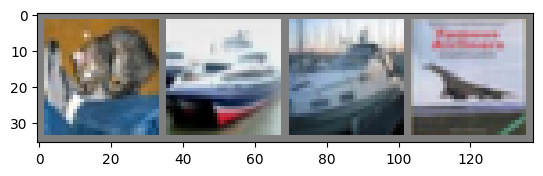

GroundTruth:    cat  ship  ship plane
Predicted:    cat   car   car  ship


In [ ]:
# test CNNs
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join('%5s' % classes[labels[j]] for j in range(4)))

# test
outputs = net(images)
_, predicted = torch.max(outputs, 1)
print('Predicted: ', ' '.join('%5s' % classes[predicted[j]] for j in range(4)))

In [ ]:
# evaluation
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print('Accuracy of the network on the 10000 test images: %d %%' % (100 * correct / total))

class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(4):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

for i in range(10):
    print('Accuracy of %5s : %2d %%' % (classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of the network on the 10000 test images: 53 %
Accuracy of plane : 65 %
Accuracy of   car : 88 %
Accuracy of  bird : 46 %
Accuracy of   cat : 32 %
Accuracy of  deer : 49 %
Accuracy of   dog : 29 %
Accuracy of  frog : 47 %
Accuracy of horse : 66 %
Accuracy of  ship : 66 %
Accuracy of truck : 40 %


# 8-1-3

In [ ]:
!wget --content-disposition https://www.dropbox.com/scl/fi/5po3d3fidc0naqcxmv2xz/vgg.py?rlkey=2oxgap859ntip76lxfdnb7xi7&dl=0

--2026-05-11 10:13:09--  https://www.dropbox.com/scl/fi/5po3d3fidc0naqcxmv2xz/vgg.py?rlkey=2oxgap859ntip76lxfdnb7xi7
Resolving www.dropbox.com (www.dropbox.com)... 162.125.65.18, 2620:100:6021:18::a27d:4112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.65.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc12da049d92368572ad3a4786a8.dl.dropboxusercontent.com/cd/0/inline/DAT7jq65wHpn01C_bm73Jw0FvV0198Y5Hna3RjtutnrMFuUHFRM8v0QfDMPzinUB4brLFMh1UbCJJWhYd04qZOTXqKJ6kqAXR6wJmU5L00cJfeFbRCF8Wgou8DFmOkejtQaZiF52oHeNlOk-JuS-yFod/file# [following]
--2026-05-11 10:13:11--  https://uc12da049d92368572ad3a4786a8.dl.dropboxusercontent.com/cd/0/inline/DAT7jq65wHpn01C_bm73Jw0FvV0198Y5Hna3RjtutnrMFuUHFRM8v0QfDMPzinUB4brLFMh1UbCJJWhYd04qZOTXqKJ6kqAXR6wJmU5L00cJfeFbRCF8Wgou8DFmOkejtQaZiF52oHeNlOk-JuS-yFod/file
Resolving uc12da049d92368572ad3a4786a8.dl.dropboxusercontent.com (uc12da049d92368572ad3a4786a8.dl.dropboxusercontent.com)... 162.125.2.15, 2620:100:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
import torchvision
import torchvision.transforms as transforms
import os
import argparse
from vgg import *

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
best_acc = 0  # best test accuracy
start_epoch = 0  # start from epoch 0 or last checkpoint epoch

In [ ]:
# Data
print('==> Preparing data..')
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=100, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

==> Preparing data..


In [ ]:
# Model
print('==> Building model..')
net = VGG('VGG19')
net = net.to(device)
if device == 'cuda':
    net = torch.nn.DataParallel(net)
    cudnn.benchmark = True

==> Building model..


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

In [ ]:
# Training
def train(epoch):
    print('\nEpoch: %d' % epoch)
    net.train()
    train_loss = 0
    correct = 0
    total = 0
    for batch_idx, (inputs, targets) in enumerate(trainloader):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        if (batch_idx%5==0): print('[Train] Loss: %.3f | Acc: %.3f%% (%d/%d)' % (train_loss/(batch_idx+1), 100.*correct/total, correct, total))

In [ ]:
def test(epoch):
    global best_acc
    net.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(testloader):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = net(inputs)
            loss = criterion(outputs, targets)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            print('[Test] Loss: %.3f | Acc: %.3f%% (%d/%d)' % (test_loss/(batch_idx+1), 100.*correct/total, correct, total))

#    # Save checkpoint.
#    acc = 100.*correct/total
#    if acc > best_acc:
#        print('Saving..')
#        state = {
#            'net': net.state_dict(),
#            'acc': acc,
#            'epoch': epoch,
#        }
#        if not os.path.isdir('checkpoint'):
#            os.mkdir('checkpoint')
#        torch.save(state, './checkpoint/ckpt.pth')
#        best_acc = acc

In [ ]:
for epoch in range(start_epoch, start_epoch+200):
    train(epoch)
    test(epoch)

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
[Train] Loss: 0.393 | Acc: 87.351% (37009/42368)
[Train] Loss: 0.393 | Acc: 87.340% (37563/43008)
[Train] Loss: 0.393 | Acc: 87.333% (38119/43648)
[Train] Loss: 0.394 | Acc: 87.299% (38663/44288)
[Train] Loss: 0.394 | Acc: 87.286% (39216/44928)
[Train] Loss: 0.395 | Acc: 87.226% (39747/45568)
[Train] Loss: 0.395 | Acc: 87.234% (40309/46208)
[Train] Loss: 0.396 | Acc: 87.214% (40858/46848)
[Train] Loss: 0.397 | Acc: 87.197% (41408/47488)
[Train] Loss: 0.397 | Acc: 87.178% (41957/48128)
[Train] Loss: 0.397 | Acc: 87.207% (42529/48768)
[Train] Loss: 0.397 | Acc: 87.211% (43089/49408)
[Train] Loss: 0.398 | Acc: 87.184% (43592/50000)
[Test] Loss: 0.423 | Acc: 89.000% (89/100)
[Test] Loss: 0.443 | Acc: 85.500% (171/200)
[Test] Loss: 0.462 | Acc: 84.667% (254/300)
[Test] Loss: 0.535 | Acc: 83.000% (332/400)
[Test] Loss: 0.520 | Acc: 83.600% (418/500)
[Test] Loss: 0.480 | Acc: 84.667% (508/600)
[Test] Loss: 0.493 | Acc: 84.714% (593/700)
[Test] Loss: 0.502 |